In [5]:

import matplotlib.pyplot as plt
import pandas as pd

In [4]:
ls

'balanco de radiacao.ipynb'   labmim_completo_2021.dat
 balanco_media_horaria.dat    labmim_completo_controle2020.dat
 balanco_media_mensal.dat     labmim-merge-2020-2021.ipynb
 files.py                     LBM_lenta_2020_03.dat
 graficos1_UFBA_v7.py         LBM_lenta_2020_04.dat
 graficos2_UFBA_v3.PY         LBM_lenta_2020.dat
 labmim_2020_2021_0.dat       LBM_rain_2020.dat
 labmim_2020_2021.dat         old/
 labmim_bruto.dat             process-bruto2horario.ipynb


In [6]:
labmim = pd.read_csv('labmim_completo_controle2020.dat',sep=';')
labmim.index = pd.to_datetime(labmim[['year','month','day','hour']])

In [7]:
labmim2 = pd.read_csv('labmim_2020_2021.dat',sep=';')
labmim2.index = pd.to_datetime(labmim2[['year','month','day','hour']])

In [8]:
header_lab = ['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS', 'u', 'v', 'precip', 'Sw_dw', 'Sw_up', 'Lw_dw', 'Lw_up', 'Sw_dif', 'Sw_par', 'RH_WXT', 'Temp_WXT', 'Net_CNR1', 'Net_NRLite']
header_teo = ['oc_topo', 'decl_rad', 'elev_solar', 'ang_hor', 'ang_zen', 'ang_hor_por', 'nascer_h', 'por_h', 'ast_h', 'fc']
header = header_lab + header_teo

In [9]:
header

['year',
 'month',
 'day',
 'hour',
 'T',
 'Td',
 'ur',
 'pressure',
 'WD',
 'WS',
 'u',
 'v',
 'precip',
 'Sw_dw',
 'Sw_up',
 'Lw_dw',
 'Lw_up',
 'Sw_dif',
 'Sw_par',
 'RH_WXT',
 'Temp_WXT',
 'Net_CNR1',
 'Net_NRLite',
 'oc_topo',
 'decl_rad',
 'elev_solar',
 'ang_hor',
 'ang_zen',
 'ang_hor_por',
 'nascer_h',
 'por_h',
 'ast_h',
 'fc']

In [10]:
labmim2.rename(columns = {'CM3Up_Wm2_Avg':'Sw_dw',
    'CM3Dn_Wm2_Avg':'Sw_up',
    'CG3Up_Wm2Cr_Avg':'Lw_dw',
    'CG3Dn_Wm2Cr_Avg':'Lw_up',
    'CMP21_Wm2_Avg':'Sw_dif',
    'RH_WXT_Avg':'RH_WXT',
    'Pmb_WXT':'pressure',
    'Temp_WXT_Avg':'Temp_WXT',
    'WS_WXT_Avg':'WS',
    'WD_WXT_Avg':'WD',
    'Temp1_Avg':'T',
    'RH1_Avg':'ur',
    'PAR_Wm2_Avg':'Sw_par',
    'Net_Wm2_Avg':'Net_CNR1',
    'NRLite_Wm2Cr_Avg':'Net_NRLite'
    }, inplace=True)

In [11]:
final = pd.merge_ordered(labmim, labmim2)

In [12]:
final = final[header]
final.index = pd.to_datetime(final[['year','month','day','hour']])

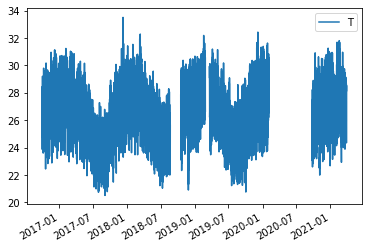

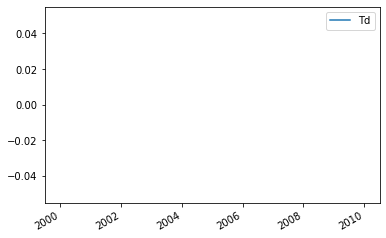

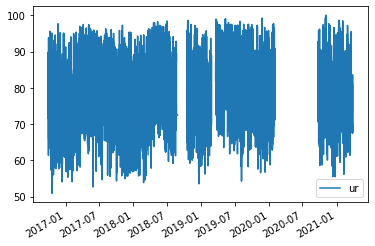

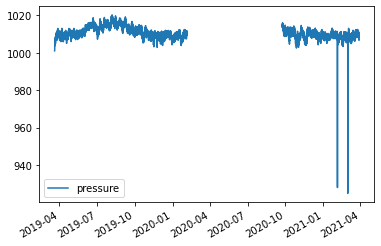

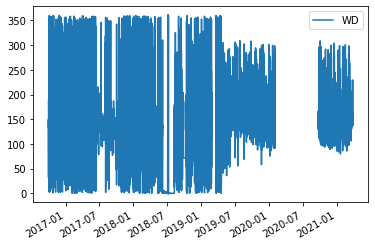

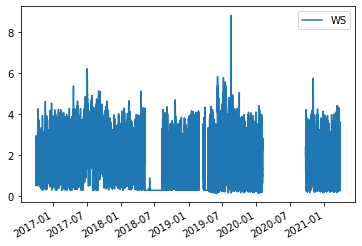

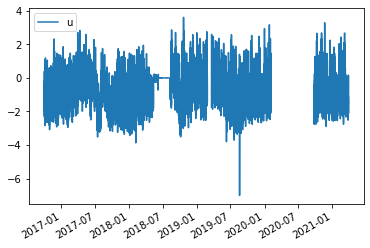

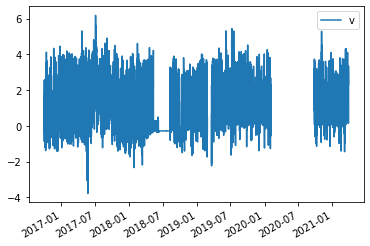

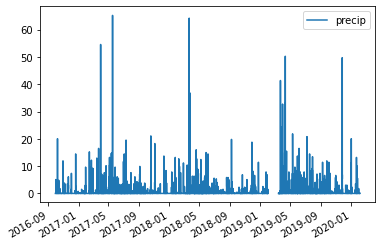

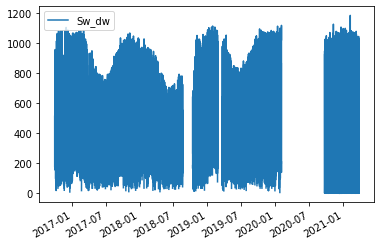

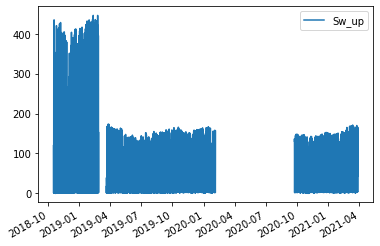

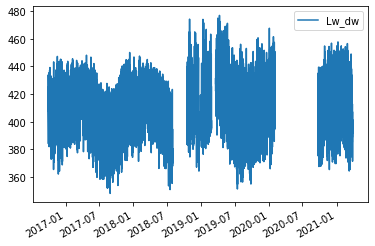

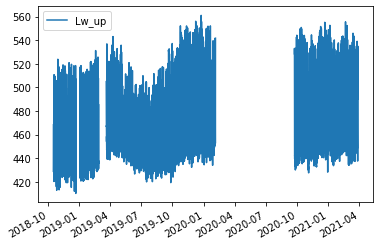

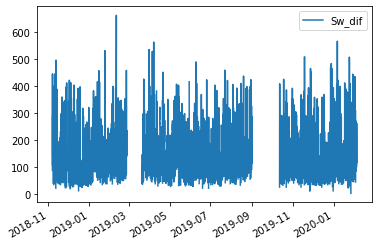

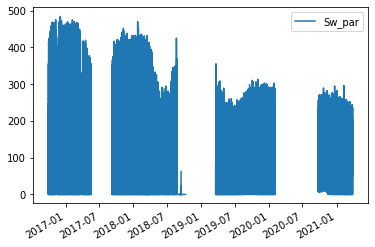

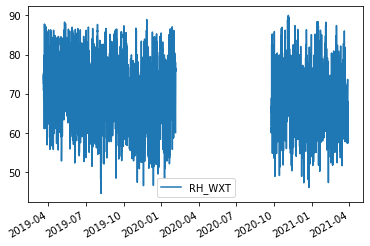

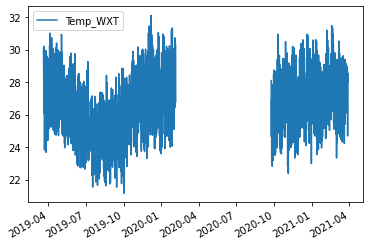

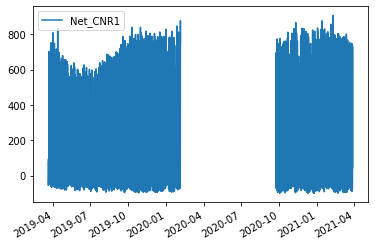

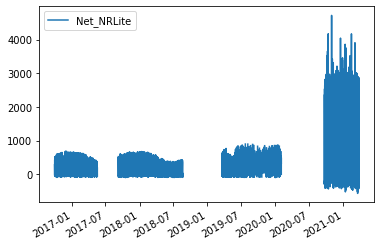

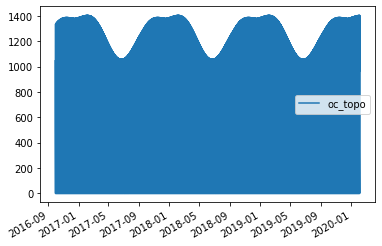

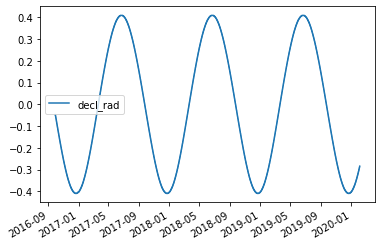

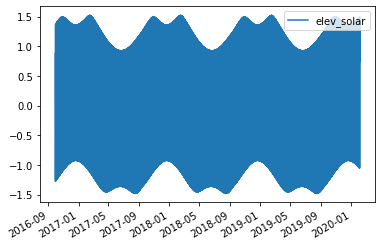

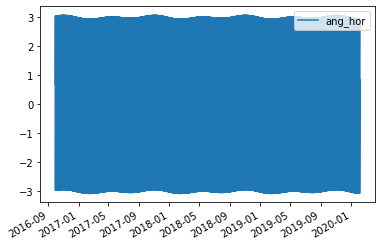

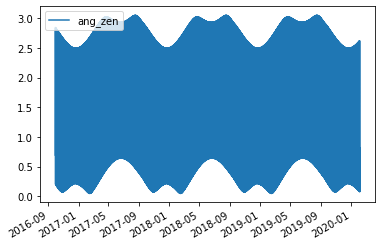

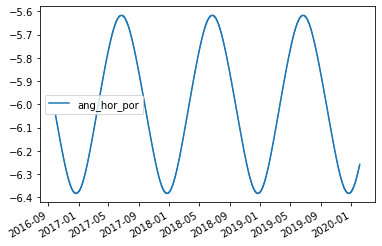

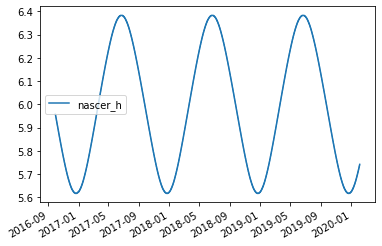

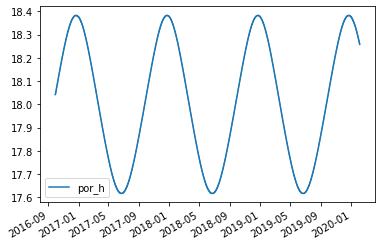

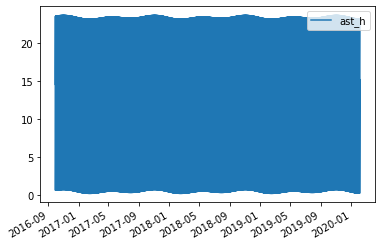

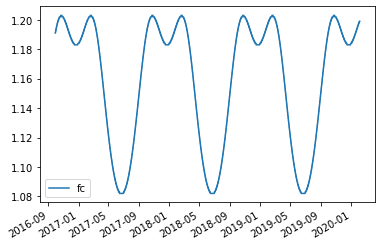

In [33]:
for col in final.columns:
    if col not in ['year', 'month', 'day', 'hour']:
        final[col].plot(label=col)
        plt.legend()
        plt.show()
        plt.close()

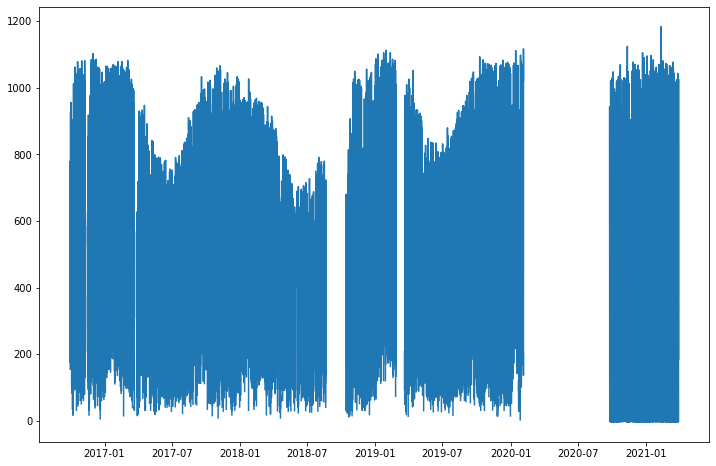

In [45]:
plt.figure(figsize=(12,8))
plt.plot(final.index, final['Sw_dw'])

<AxesSubplot:>

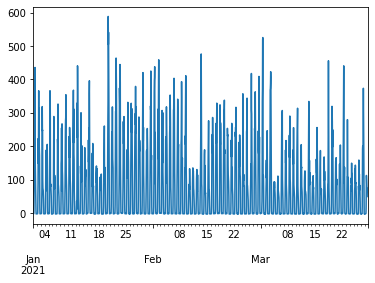

In [15]:
final['2021']['Sw_dif'].plot()

In [16]:
final.to_csv('labmim_completo_2021.dat',na_rep='nan',sep=';',index=False)